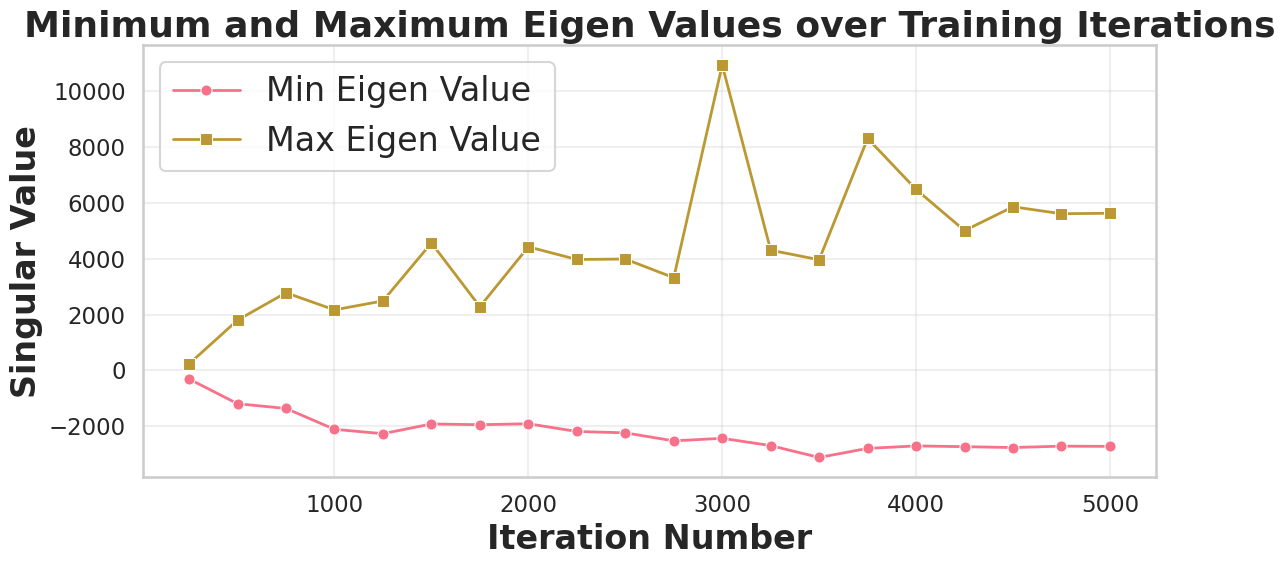

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read your CSV file
df = pd.read_csv('hessian_eigenvalues_adagram_best.csv')

# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create figure
plt.figure(figsize=(12, 6))

# Plot both curves
sns.lineplot(data=df, x='iter_num', y='min_sv', marker='o', linewidth=2, markersize=8, label='Min Eigen Value')
sns.lineplot(data=df, x='iter_num', y='max_sv', marker='s', linewidth=2, markersize=8, label='Max Eigen Value')

# Customize the plot
plt.xlabel('Iteration Number', fontsize=24, fontweight='bold')
plt.ylabel('Singular Value', fontsize=24, fontweight='bold')
plt.title('Minimum and Maximum Eigen Values over Training Iterations', fontsize=26, fontweight='bold')
plt.legend(fontsize=24, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('adagram_best_eigen_values_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()


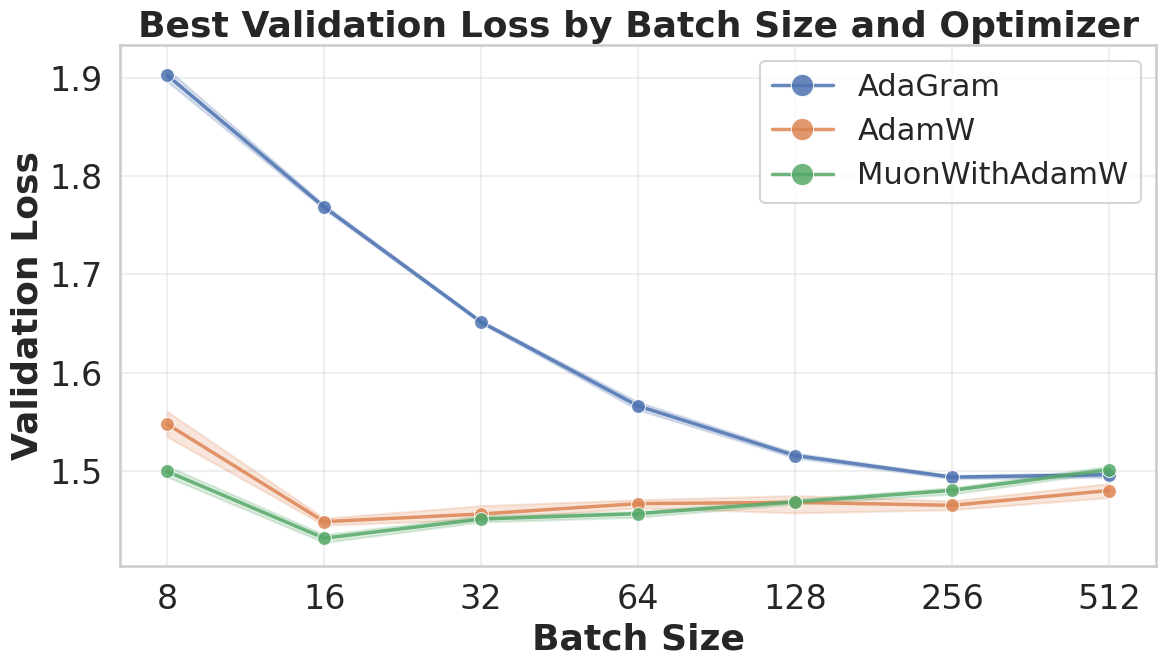

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_results = pd.read_csv("batch_results.csv", index_col=0)
best_results["batch_size"] = best_results["batch_size"].astype(int)
best_results["seed"] = best_results["seed"].astype(int)
best_results = best_results[best_results["seed"].isin([2, 3, 4, 5])].copy()

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

ax = sns.lineplot(
    data=best_results,
    x="batch_size",
    y="val_loss",
    hue="optimizer_name",
    marker="o",
    markersize=10,
    linewidth=2.5,
    alpha=0.85,
    err_style="band",
    errorbar=("ci", 95),
)

plt.xlabel("Batch Size", fontsize=26, fontweight="bold")
plt.ylabel("Validation Loss", fontsize=26, fontweight="bold")
plt.title("Best Validation Loss by Batch Size and Optimizer", fontsize=26, fontweight="bold")

plt.xscale("log")
batch_sizes = [8, 16, 32, 64, 128, 256, 512]
plt.xticks(batch_sizes, [str(bs) for bs in batch_sizes])

# Bigger ticks
ax.tick_params(axis="both", which="major", labelsize=24)  # tick label size [web:56]

# Bigger legend (text + markers)
leg = ax.legend(
    loc="best",
    frameon=True,
    fontsize=22,
    title_fontsize=22,   # if you keep a legend title [web:60]
    markerscale=1.6,     # enlarges marker symbols in legend [web:67]
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("best_val_loss_by_batch_size_ci.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
results_df.head()

,optimizer,batch_size,learning_rate,best_val_loss,best_epoch,config
0,AdaGrad,128,0.0001,2.530987,4750,AdaGrad (lr=0.0001)
1,AdaGrad,128,0.001,2.574563,3250,AdaGrad (lr=0.001)
2,AdaGrad,128,0.01,2.534035,4750,AdaGrad (lr=0.01)
3,AdaGrad,128,1e-05,2.563007,5000,AdaGrad (lr=1e-05)
12,AdaGram,128,0.0001,2.535578,5000,AdaGram (lr=0.0001)


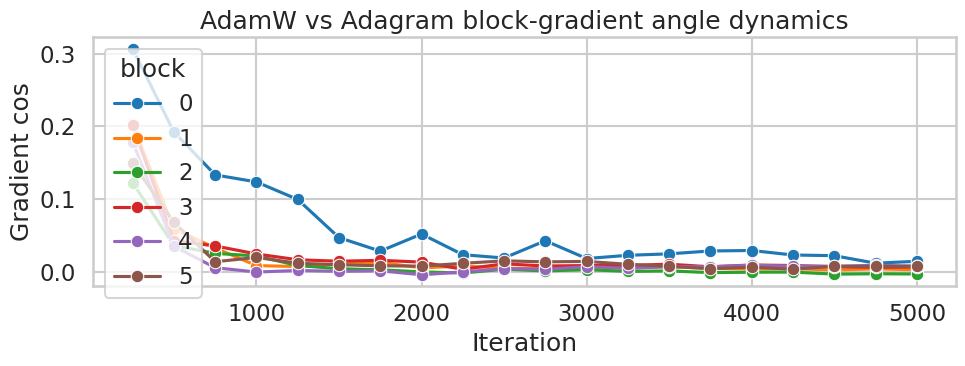

In [10]:
# plot_angles_sns.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")  # seaborn theme/style [web:333]

files = {
    "adamw_vs_adagram": "block_grad_angle_adagram_adamw.csv",
    # "sgd_vs_adagram":   "block_grad_angle_adagram_sgd.csv",
    # "sgd_vs_adamw":     "block_grad_angle_adamw_sgd.csv",
}

dfs = []
for label, path in files.items():
    df = pd.read_csv(path)
    df["label"] = label
    dfs.append(df[["iter", "attn_grad_angle_cos", "label", "block"]])

data = pd.concat(dfs, ignore_index=True).sort_values(["label", "iter"])

plt.figure(figsize=(10, 4))
ax = sns.lineplot(
    data=data,
    x="iter",
    y="attn_grad_angle_cos",
    hue="block",
    marker="o",
    palette="tab10"
)  # hue groups lines by label [web:325]

ax.set_xlabel("Iteration")
ax.set_ylabel("Gradient cos")
ax.set_title("AdamW vs Adagram block-gradient angle dynamics")
plt.tight_layout()
plt.savefig("grad_angle_dynamics_sns.png", dpi=200)
plt.show()


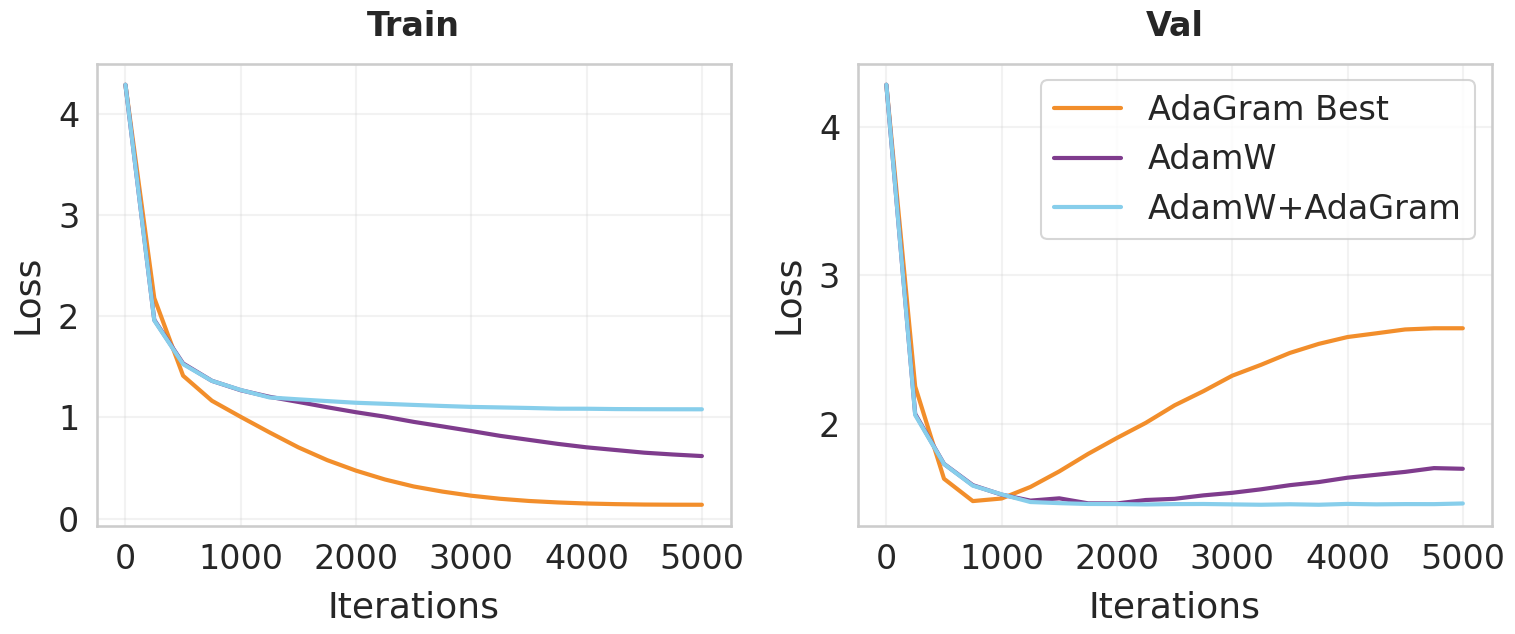

<Figure size 640x480 with 0 Axes>

In [2]:
from clearml import Task, Logger
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Updated task names to match your legend
TASKS = {
    "AdaGram Best":   "6ff2169479424a30ab403a35260fbba1",
    "AdamW":         "2e56fbea5ec84412a95832b7aba07c9f", 
    "AdamW+AdaGram":   "d9a32d865ed54a5da90e0bc528a73221",
}

# Colors from your legend image (orange, purple, teal)
COLORS = {
    "AdaGram Best":  "#f28e2b",
    "AdamW":         "#7f3c8d",
    "AdamW+AdaGram": "#87CEEB",
}

MARKERS = {
    "AdaGram Best":  "o",      
    "AdamW":         "s",      
    "AdamW+AdaGram": "^",      
}

# Data collection
model_order = list(TASKS.keys())
palette = [COLORS[m] for m in model_order]        # Exact colors!
markers = [MARKERS[m] for m in model_order]       # Exact markers!


data = []
for name, tid in TASKS.items():
    t = Task.get_task(task_id=tid)
    scalars = t.get_reported_scalars()
    loss = scalars["loss"]  # Assumes "loss" key exists
    
    # Train data
    tr = loss["train"]
    df_tr = pd.DataFrame({
        "iteration": tr["x"], 
        "loss": tr["y"], 
        "model": name, 
        "split": "train"
    })
    data.append(df_tr)
    
    # Val data
    va = loss["val"]
    df_va = pd.DataFrame({
        "iteration": va["x"], 
        "loss": va["y"], 
        "model": name, 
        "split": "val"
    })
    data.append(df_va)

df = pd.concat(data, ignore_index=True)  # ← df created here!

fig, (ax_tr, ax_va) = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(context="talk", style="whitegrid")

# Train: hue=style → uses YOUR colors + markers
sns.lineplot(data=df[df.split=="train"], x="iteration", y="loss", 
             hue="model",  palette=palette, 
             linewidth=3, estimator=None, ax=ax_tr, legend="brief")

# Val: same but legend=False
sns.lineplot(data=df[df.split=="val"], x="iteration", y="loss", 
             hue="model",  palette=palette, 
             linewidth=3, estimator=None, ax=ax_va, legend=False)

ax_tr.set_title("Train", fontsize=24, fontweight='bold', pad=20)
ax_va.set_title("Val", fontsize=24, fontweight='bold', pad=20)

for ax in (ax_tr, ax_va):
    ax.set_xlabel("Iterations", fontsize=26, labelpad=10)
    ax.set_ylabel("Loss", fontsize=26, labelpad=10)
    ax.tick_params(labelsize=24)
    ax.grid(True, alpha=0.25)

# Big right legend from train plot
handles, labels = ax_tr.get_legend_handles_labels()
ax_va.legend(handles, labels, loc="upper right", 
             frameon=True, fontsize=24, fancybox=True,)
ax_tr.legend_.remove()  # Still hide train legend

plt.savefig("nano_loss_comparison.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

plt.tight_layout()  # Normal tight_layout only
plt.show()
logger = Logger.current_logger()
# logger.report_matplotlib_figure(title="loss", series="sns_colors_markers", figure=fig, iteration=0)

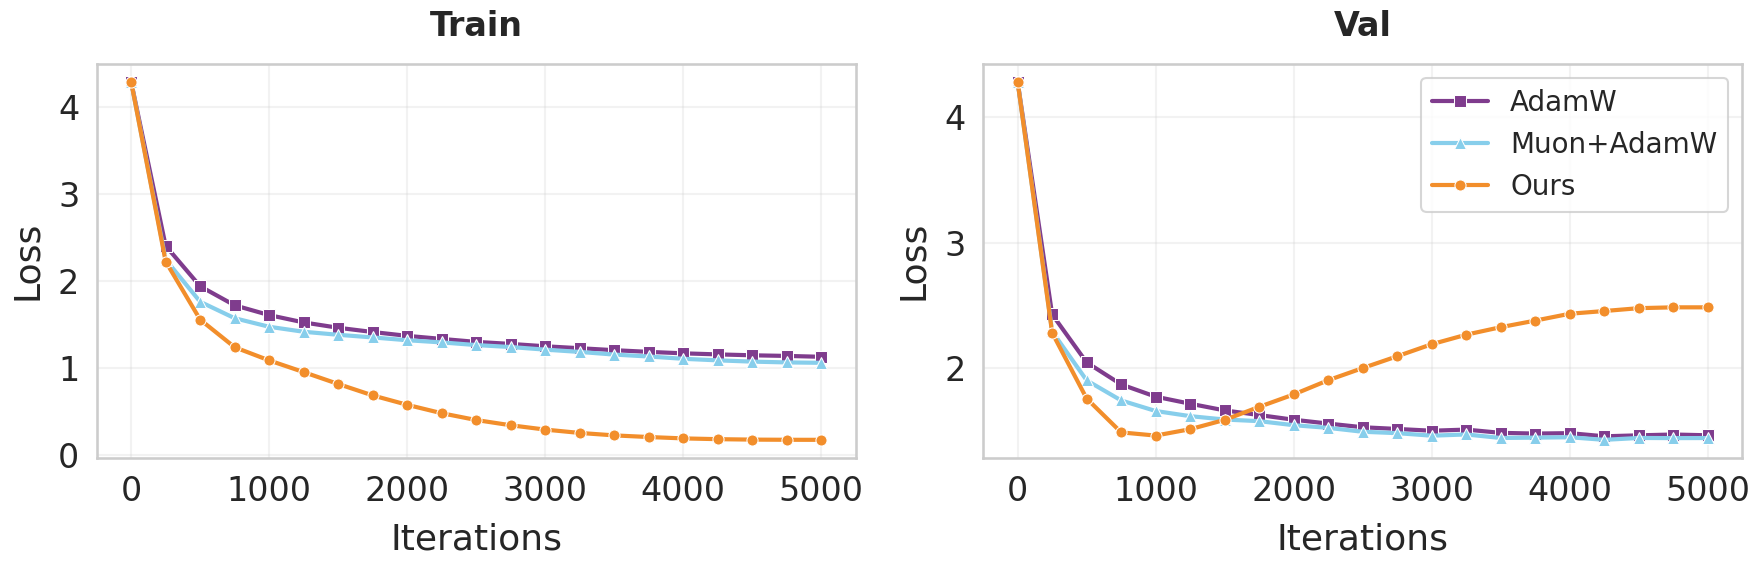

In [4]:
from clearml import Task, Logger
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


TASKS = {
    "AdamW":    "d88ca9d8e75f48928609acafb9ac499c",
    "Muon+AdamW":       "f9087e1880cd4270a7685cd94b917208",
    "Ours":             "f52b1017f6ce45ec9fe55aea8009dad7",
}

COLORS = {
    "AdamW": "#7f3c8d",   # purple
    "Muon+AdamW":    "#87CEEB",   # light blue
    "Ours":          "#f28e2b",   # orange
}

MARKERS = {
    "AdamW": "s",
    "Muon+AdamW":    "^",
    "Ours":          "o",
}


data = []
model_order = list(TASKS.keys())

for name, tid in TASKS.items():
    t = Task.get_task(task_id=tid)
    scalars = t.get_reported_scalars()
    loss = scalars["loss"]

    tr = loss["train"]
    df_tr = pd.DataFrame({
        "iteration": tr["x"],
        "loss": tr["y"],
        "model": name,
        "split": "train",
    })
    data.append(df_tr)

    va = loss["val"]
    df_va = pd.DataFrame({
        "iteration": va["x"],
        "loss": va["y"],
        "model": name,
        "split": "val",
    })
    data.append(df_va)

df = pd.concat(data, ignore_index=True)


sns.set_theme(context="talk", style="whitegrid")
fig, (ax_tr, ax_va) = plt.subplots(1, 2, figsize=(18, 6))

common_plot_kwargs = dict(
    x="iteration",
    y="loss",
    hue="model",
    style="model",
    hue_order=model_order,
    style_order=model_order,
    palette=COLORS,
    markers=MARKERS,
    dashes=False,
    linewidth=3,
    markersize=8,
    estimator=None,
)

sns.lineplot(
    data=df[df["split"] == "train"],
    ax=ax_tr,
    legend=True,
    **common_plot_kwargs,
)

sns.lineplot(
    data=df[df["split"] == "val"],
    ax=ax_va,
    legend=False,
    **common_plot_kwargs,
)

ax_tr.set_title("Train", fontsize=24, fontweight="bold", pad=20)
ax_va.set_title("Val", fontsize=24, fontweight="bold", pad=20)

for ax in (ax_tr, ax_va):
    ax.set_xlabel("Iterations", fontsize=26, labelpad=10)
    ax.set_ylabel("Loss", fontsize=26, labelpad=10)
    ax.tick_params(labelsize=24)
    ax.grid(True, alpha=0.25)

handles, labels = ax_tr.get_legend_handles_labels()
ax_va.legend(
    handles,
    labels,
    loc="upper right",
    frameon=True,
    fontsize=20,
    fancybox=True,
    title=None,
)

if ax_tr.legend_ is not None:
    ax_tr.legend_.remove()

plt.tight_layout()
plt.savefig("nano_loss_comparison.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

logger = Logger.current_logger()
# logger.report_matplotlib_figure(
#     title="loss",
#     series="nanoGPT_vs_muon_vs_ours",
#     figure=fig,
#     iteration=0,
# )

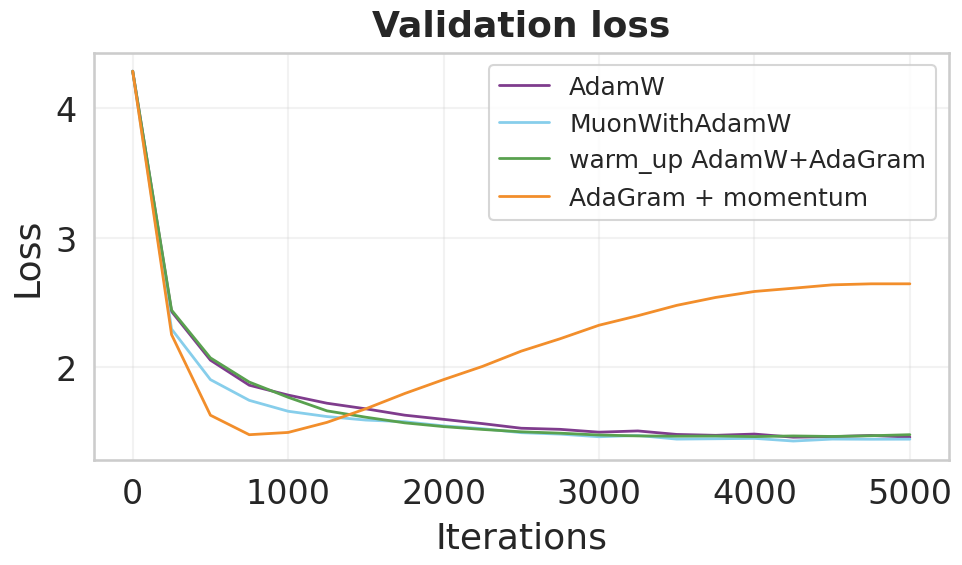

In [ ]:
from clearml import Task
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TASKS = {
    "AdamW":                 "165a062401724af3b3a673065eaf04e7",
    "MuonWithAdamW":         "f9087e1880cd4270a7685cd94b917208",
    "warm_up AdamW+AdaGram": "d901aeccc68e4ff8bd7c88393701f826",
    # "AdaGramEQ rank 1":      "d25205516dad49bd8e968d1ad22d12dc",
    "AdaGram + momentum":      "6ff2169479424a30ab403a35260fbba1",
    # "AdaGram":               "28ffb5291e91472d8ce6b9d3172478d4"
}

COLORS = {
    "AdamW":                 "#7f3c8d",
    "MuonWithAdamW":         "#87CEEB",
    "warm_up AdamW+AdaGram": "#59a14f",
    "AdaGramEQ rank 1":      "#72BAA9",
    "AdaGram": "#59a14f",
    "AdaGram + momentum":      "#f28e2b",

}

def _first_series_xy(title_dict: dict):
    """Given scalars[title] = {series_name: {'x':..,'y':..}, ...}, pick the first series."""
    series_names = list(title_dict.keys())
    if not series_names:
        raise KeyError("Title exists but has no series")
    s0 = series_names[0]
    d = title_dict[s0]
    return d["x"], d["y"], s0

def get_val_loss_xy(scalars: dict):
    # Case A: title="loss", series="val"
    if "loss" in scalars and "val" in scalars["loss"]:
        d = scalars["loss"]["val"]
        return d["x"], d["y"], ("loss", "val")

    # Case B: title itself is "val_loss" (your failing task shows this in Available titles)
    if "val_loss" in scalars:
        x, y, s = _first_series_xy(scalars["val_loss"])
        return x, y, ("val_loss", s)

    # Case C: sometimes it’s "validation_loss" or similar
    for cand in ["validation_loss", "valid_loss", "val/loss", "validation/loss"]:
        if cand in scalars:
            x, y, s = _first_series_xy(scalars[cand])
            return x, y, (cand, s)

    raise KeyError(f"No validation-loss scalar found. Available titles: {list(scalars.keys())}")

rows = []
for name, tid in TASKS.items():
    t = Task.get_task(task_id=tid)
    scalars = t.get_reported_scalars()  # nested dict title->series->x/y [web:22]

    x, y, where = get_val_loss_xy(scalars)
    rows.append(pd.DataFrame({
        "iteration": x,
        "val_loss":  y,
        "model":     name,
        "source":    f"{where[0]}/{where[1]}",
    }))

df_va = pd.concat(rows, ignore_index=True)

sns.set_theme(context="talk", style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_va,
    x="iteration",
    y="val_loss",
    hue="model",
    hue_order=list(TASKS.keys()),
    palette=COLORS,      # dict palette keyed by hue levels [web:16]
    linewidth=2,
    estimator=None,      # plot raw series (no aggregation) [web:16]
    ax=ax,
)

ax.set_title("Validation loss", fontsize=26, fontweight="bold", pad=12)
ax.set_xlabel("Iterations", fontsize=26, labelpad=8)
ax.set_ylabel("Loss", fontsize=26, labelpad=8)
ax.tick_params(labelsize=24)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True, fancybox=True, title=None, fontsize=18)

plt.tight_layout()
plt.savefig("nanogpt_mom_adagram_val_loss_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()
